In [1]:
from alerce.core import Alerce
import pandas as pd
from astropy.table import vstack, Table
import matplotlib.pyplot as plt
import pyvo as vo
import requests
import sqlalchemy as sa
import sys
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
import re
import george
import scipy.optimize as op
import emcee
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.preprocessing import RobustScaler

In [2]:
#load in data
sn1a1 = Table.read("../Data/SNIa_fits1.ecsv")
sn1a2 = Table.read("../Data/SNIa_fits2.ecsv")
snII = Table.read("../Data/SNII_fits.ecsv")
snIb = Table.read("../Data/SNIb_fits.ecsv")
snIc = Table.read("../Data/SNIc_fits.ecsv")

In [3]:
#initialize features
rises = []
falls = []
peaks = []
label = []

#create iterable list of tables
SNe = [sn1a1, sn1a2, snII, snIb, snIc]

#initialize encoding of labels
encoder = np.array(["SNIa", "SNII", "SNIb", "SNIc"])

#iterate through tables
for sn in SNe:

    #iterate through features in a table
    for stype, peak, rise, fall in zip(sn["type"], sn["peak"], sn["rise"], sn["fall"]):

        #encode label to number i.e. SNIa to 0
        l = np.where(encoder == stype)[0]

        #build feature lists
        rises.append(rise)
        falls.append(fall)
        peaks.append(peak)

        #build list of encoded labels
        label.append(l)

#convert lists to numpy arrays
rises = np.array(rises)
falls = np.array(falls)
peaks = np.array(peaks)

In [4]:
#build feature space as Table
features = Table([rises, peaks, falls], names=["Rise", "Peak", "Fall"]).to_pandas()

In [5]:
#normalize data using median absolute deviation
transformer = RobustScaler().fit(features)
features_n = transformer.transform(features)

In [6]:
#resample feature space
resampler = SMOTE(sampling_strategy="auto", k_neighbors=3)
features_resampled, labels_resampled = resampler.fit_resample(features_n, label)

In [7]:
#initialize ml
clf = RandomForestClassifier(max_depth=None, random_state=0)

#use ml with cross validation
predict_clf = cross_val_predict(clf, features_resampled, labels_resampled)

#convert to data frame for plotting
features_resampled = pd.DataFrame(features_resampled)

array([[<Axes: xlabel='0', ylabel='0'>, <Axes: xlabel='1', ylabel='0'>,
        <Axes: xlabel='2', ylabel='0'>],
       [<Axes: xlabel='0', ylabel='1'>, <Axes: xlabel='1', ylabel='1'>,
        <Axes: xlabel='2', ylabel='1'>],
       [<Axes: xlabel='0', ylabel='2'>, <Axes: xlabel='1', ylabel='2'>,
        <Axes: xlabel='2', ylabel='2'>]], dtype=object)

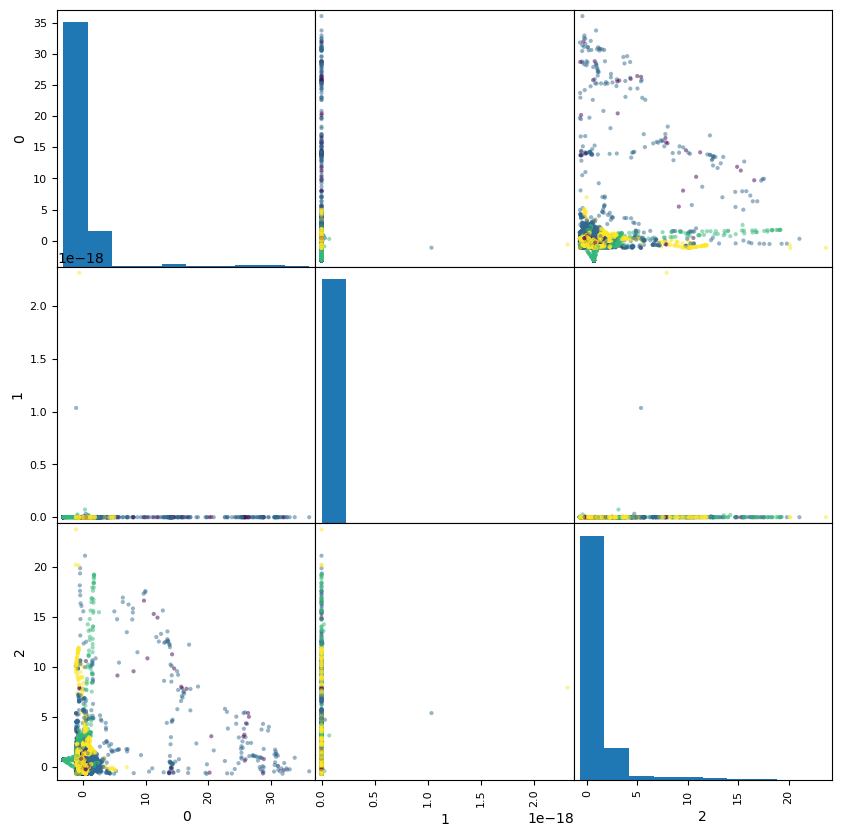

In [8]:
pd.plotting.scatter_matrix(features_resampled, figsize=(10,10), c=predict_clf, cmap="viridis")

In [9]:
#calculate absolute accuracy
print(f"Accuracy: {np.sum((predict_clf == labels_resampled))/len(labels_resampled)}")

Accuracy: 0.7302857142857143


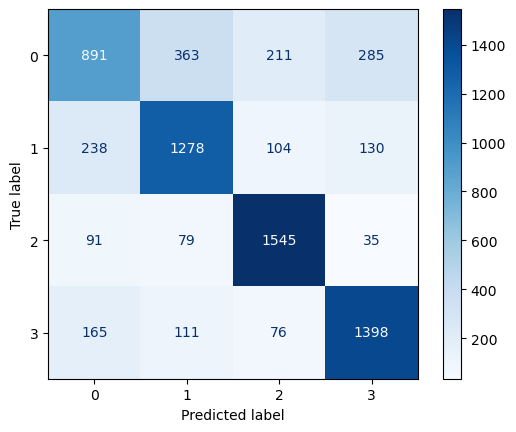

In [10]:
#generate confusion matrix
confusion_matrix = metrics.cluster.contingency_matrix(labels_resampled, predict_clf)

#plot confusion matrix
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()

Text(0.5, 0.98, 'Normalized by Row')

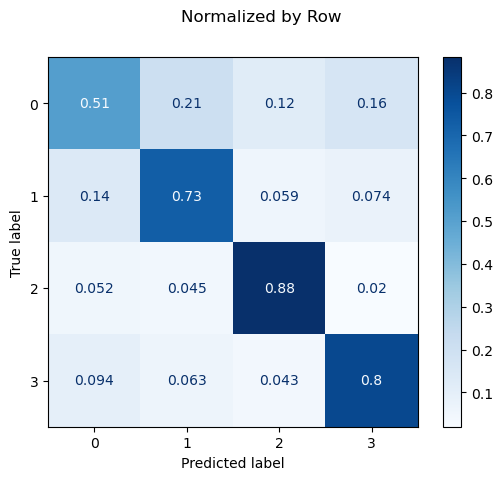

In [11]:
#generate and plot confusion matrix normalized across rows
confusion_matrix_row = metrics.confusion_matrix(labels_resampled, predict_clf, normalize="true")
disp2 = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_row)
disp2.plot(cmap=plt.cm.Blues)
plt.suptitle("Normalized by Row")

Text(0.5, 0.98, 'Normalized by Col')

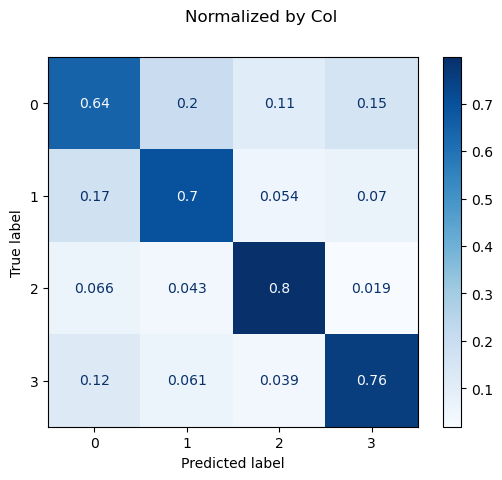

In [12]:
#generate and plot confusion matrix normalized across columns
confusion_matrix_row = metrics.confusion_matrix(labels_resampled, predict_clf, normalize="pred")
disp2 = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_row)
disp2.plot(cmap=plt.cm.Blues)
plt.suptitle("Normalized by Col")